In [1]:
import sys; sys.path.append("..")
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, polars as pl, joblib
import matplotlib.pyplot as plt
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import (proportion_effectsize, proportions_ztest,
                                          confint_proportions_2indep, proportion_confint)
from src.features import FEATURES

te = pd.read_parquet("../data/processed/test_scored.parquet")
bundle = joblib.load("../models/scamshield.joblib")
lr = bundle["logreg"]

ALERT_RATE = 0.01      # each arm flags its riskiest 1% of payments
print(te.shape, "| fraud cases:", int(te["isFraud"].sum()))

(416297, 22) | fraud cases: 4020


In [2]:
feat = pl.read_parquet("../data/processed/features.parquet")
val = feat.filter((pl.col("step") > 322) & (pl.col("step") <= 376))
X_va, y_va = val.select(FEATURES).to_pandas(), val["isFraud"].to_numpy()

p_va_lr = lr.predict_proba(X_va)[:, 1]
k = int(len(p_va_lr) * ALERT_RATE)
top_k = np.argsort(-p_va_lr)[:k]
baseline_recall = y_va[top_k].sum() / y_va.sum()
print(f"Champion's recall on validation at a {ALERT_RATE:.0%} alert budget: {baseline_recall:.3f}")

Champion's recall on validation at a 1% alert budget: 0.859


In [3]:
target = min(baseline_recall + 0.05, 0.99)
es = proportion_effectsize(target, baseline_recall)
n_per_arm = NormalIndPower().solve_power(effect_size=es, alpha=0.05, power=0.8,
                                         alternative="larger")

fraud_per_day = te.groupby("day")["isFraud"].sum().mean()
days_needed = int(np.ceil(n_per_arm / (fraud_per_day / 2)))

print(f"Detect {baseline_recall:.3f} → {target:.3f} (5-point uplift)")
print(f"Fraud cases needed per arm: {n_per_arm:.0f}")
print(f"Fraud cases per day in each arm: ~{fraud_per_day/2:.0f}")
print(f"Experiment length needed: ~{days_needed} day(s)")
print(f"Fraud cases available per arm in the test set: ~{te['isFraud'].sum()/2:.0f}")

Detect 0.859 → 0.909 (5-point uplift)
Fraud cases needed per arm: 502
Fraud cases per day in each arm: ~126
Experiment length needed: ~4 day(s)
Fraud cases available per arm in the test set: ~2010


In [4]:
def run_experiment(df, col_a, col_b, seed=1, alert_rate=ALERT_RATE):
    rng = np.random.default_rng(seed)
    arm = rng.integers(0, 2, len(df))
    rows = {}
    for a, col, name in [(0, col_a, "A: champion"), (1, col_b, "B: challenger")]:
        sub = df[arm == a]
        k = int(len(sub) * alert_rate)
        alert = sub[col].rank(method="first", ascending=False) <= k
        fraud = sub["isFraud"] == 1
        rows[name] = {"payments": len(sub), "alerts": int(alert.sum()),
                      "fraud_cases": int(fraud.sum()), "caught": int((alert & fraud).sum()),
                      "false_alerts": int((alert & ~fraud).sum())}
    res = pd.DataFrame(rows).T
    res["recall"] = res["caught"] / res["fraud_cases"]
    res["precision"] = res["caught"] / res["alerts"]
    return res

In [5]:
res = run_experiment(te, "score_lr", "score", seed=1)
display(res.round(3))

A, B = res.loc["A: champion"], res.loc["B: challenger"]

# Primary metric: share of fraud caught
z, p = proportions_ztest([B.caught, A.caught], [B.fraud_cases, A.fraud_cases], alternative="larger")
lo, hi = confint_proportions_2indep(B.caught, B.fraud_cases, A.caught, A.fraud_cases)
print(f"PRIMARY  | recall uplift: {B.recall - A.recall:+.3f}  (95% CI {lo:+.3f} to {hi:+.3f}), z = {z:.2f}, p = {p:.2e}")

# Guardrail metric: legitimate payments wrongly flagged
legit_A, legit_B = A.payments - A.fraud_cases, B.payments - B.fraud_cases
z2, p2 = proportions_ztest([B.false_alerts, A.false_alerts], [legit_B, legit_A], alternative="smaller")
print(f"GUARDRAIL| false alerts: A = {int(A.false_alerts)}, B = {int(B.false_alerts)}, p (B has fewer) = {p2:.2e}")

,payments,alerts,fraud_cases,caught,false_alerts,recall,precision
A: champion,208328,2083,2030,1376,707,0.678,0.661
B: challenger,207969,2079,1990,1972,107,0.991,0.949


PRIMARY  | recall uplift: +0.313  (95% CI +0.292 to +0.334), z = 26.60, p = 3.17e-156
GUARDRAIL| false alerts: A = 707, B = 107, p (B has fewer) = 1.79e-98


In [6]:
pvals = []
for seed in range(200):
    r = run_experiment(te, "score_lr", "score_lr", seed=seed)
    a, b = r.iloc[0], r.iloc[1]
    _, pv = proportions_ztest([b.caught, a.caught], [b.fraud_cases, a.fraud_cases])
    pvals.append(pv)
pvals = np.array(pvals)
print(f"A/A test: {np.mean(pvals < 0.05):.1%} of 200 runs showed a 'significant' difference (expect ~5%)")

A/A test: 5.5% of 200 runs showed a 'significant' difference (expect ~5%)


In [7]:
uplifts = []
for seed in range(50):
    r = run_experiment(te, "score_lr", "score", seed=seed)
    uplifts.append(r.iloc[1]["recall"] - r.iloc[0]["recall"])
uplifts = np.array(uplifts)
print(f"Recall uplift across 50 random splits: min {uplifts.min():+.3f}, "
      f"median {np.median(uplifts):+.3f}, max {uplifts.max():+.3f}")

Recall uplift across 50 random splits: min +0.277, median +0.316, max +0.348


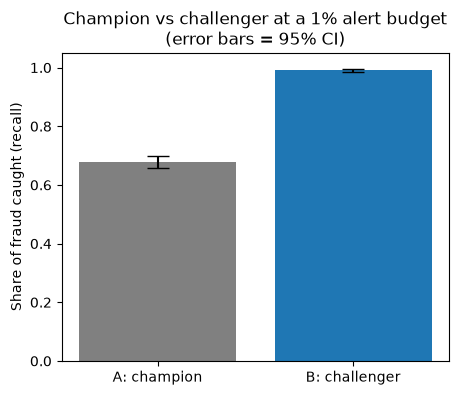

In [8]:
ci = [proportion_confint(r.caught, r.fraud_cases, method="wilson") for _, r in res.iterrows()]
err = np.array([[r - c[0] for r, c in zip(res["recall"], ci)],
                [c[1] - r for r, c in zip(res["recall"], ci)]])

plt.figure(figsize=(5, 4))
plt.bar(res.index, res["recall"], yerr=err, capsize=8, color=["grey", "tab:blue"])
plt.ylabel("Share of fraud caught (recall)"); plt.ylim(0, 1.05)
plt.title(f"Champion vs challenger at a {ALERT_RATE:.0%} alert budget\n(error bars = 95% CI)")
plt.savefig("../reports/figures/experiment_result.png", dpi=150, bbox_inches="tight")
plt.show()

## Champion vs challenger experiment

**Hypothesis:** the LightGBM challenger catches a higher share of fraud than the logistic regression champion, at the same investigator workload (1% of payments flagged per arm).

**Design:**
- Payments randomly assigned 50/50 to champion (A) or challenger (B); each arm flags exactly its riskiest 1% of payments (ranked, so workloads are identical: 2,083 vs 2,079 alerts).
- Primary metric: recall (share of fraud caught). Guardrail metric: legitimate payments wrongly flagged.
- Power analysis (done before the experiment, using validation data): to detect a 5-point uplift from a baseline recall of 0.859 with 80% power at α = 0.05, each arm needs 502 fraud cases, about 4 days of live traffic at test-period fraud volumes. The test set provides ~2,010 per arm, so the experiment is well powered.

**Result:**

| Arm | Payments | Alerts | Fraud cases | Caught | False alerts | Recall | Precision |
|---|---|---|---|---|---|---|---|
| A: champion | 208,328 | 2,083 | 2,030 | 1,376 | 707 | 67.8% | 66.1% |
| B: challenger | 207,969 | 2,079 | 1,990 | 1,972 | 107 | 99.1% | 94.9% |

- **Primary:** recall uplift of **+31.3 points** (95% CI +29.2 to +33.4), z = 26.6, p < 0.001. This is over 6x the minimum effect the experiment was designed to detect.
- **Guardrail:** false alerts fell from 707 to 107 (~85% fewer) at the same workload (p < 0.001), so the challenger improves customer experience as well as fraud detection.
- **A/A test:** 5.5% of 200 champion-vs-champion runs were "significant", close to the expected 5%, confirming the testing method does not produce excess false positives.
- **Robustness:** across 50 different random splits, the uplift ranged from +27.7 to +34.8 points (median +31.6), so the result does not depend on how payments were assigned.
- The champion's recall here (67.8%) is lower than its validation baseline (85.9%), as expected: the test period's higher fraud rate makes a 1% alert budget much tighter.

**Recommendation:** adopt the challenger. At the same investigator workload it catches substantially more fraud and wrongly flags far fewer genuine payments, and the result is statistically robust.

**Caveats for a real deployment:**
- Randomisation here is per payment, which splits PaySim's transfer/cash-out fraud pairs across arms; a real experiment would randomise per customer.
- Fraud labels arrive with a delay (often weeks), so real experiments must wait for labels before concluding.
- Running a weaker model on half of live traffic has a real cost; banks often use **shadow mode** (the challenger scores payments silently alongside the champion) before a live split.
- This is an offline simulation on historical, synthetic data, not a live test.

## Key takeaways
- Simulated a champion (logistic regression) vs challenger (LightGBM) experiment with identical investigator workload (1% of payments flagged per arm).
- Power analysis showed 502 fraud cases per arm (~4 days of live traffic) are needed to detect a 5-point uplift; the test set provided ~4x that.
- The challenger caught 99.1% of fraud vs 67.8% (+31.3 points, 95% CI +29.2 to +33.4, p < 0.001) with ~85% fewer false alerts (107 vs 707).
- An A/A test confirmed the method's false-alarm rate is ~5% (5.5% observed), and the uplift held across 50 random splits (+27.7 to +34.8 points).
- Recommendation: adopt the challenger, ideally after a shadow-mode period with per-customer randomisation.